In [32]:
import kagglehub
import pandas as pd


# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
Path to dataset files: /kaggle/input/ecommerce-behavior-data-from-multi-category-store


In [33]:
import os
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


# 1. איתור קובץ ה-CSV מתוך התיקייה שהורדנו
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_to_load = os.path.join(path, csv_files[0])
print(f"Loading data from: {csv_files[0]}")

# 2. טעינת מיליון שורות בלבד כדי לשמור על ביצועים מהירים
print("Reading CSV into Pandas... (this will take a few seconds)")
df = pd.read_csv(file_to_load, nrows=1000000)

# 3. הקמת מסד נתונים SQL מקומי והזרקת הנתונים לטבלה בשם 'user_events'
print("Transferring data to SQLite database...")
conn = sqlite3.connect('ecommerce.db')
df.to_sql('user_events', conn, if_exists='replace', index=False)
print("Success! Table 'user_events' is ready for queries.")

# 4. הרצת שאילתת SQL ראשונה לבדיקה שהכל עובד
test_query = """
SELECT *
FROM user_events
LIMIT 5;
"""
display(pd.read_sql(test_query, conn))

Loading data from: 2019-Nov.csv
Reading CSV into Pandas... (this will take a few seconds)
Transferring data to SQLite database...
Success! Table 'user_events' is ready for queries.


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [34]:
#מציאת האנשים שהוסיפו לעגלה

cart_query = """
SELECT *
FROM user_events
WHERE event_type = 'cart'
"""

display(pd.read_sql(cart_query, conn))

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:14 UTC,cart,1005014,2053013555631882655,electronics.smartphone,samsung,503.09,533326659,6b928be2-2bce-4640-8296-0efdf2fda22a
1,2019-11-01 00:03:24 UTC,cart,1801881,2053013554415534427,electronics.video.tv,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e
2,2019-11-01 00:03:39 UTC,cart,1005115,2053013555631882655,electronics.smartphone,apple,949.47,565865924,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e
3,2019-11-01 00:05:54 UTC,cart,1002542,2053013555631882655,electronics.smartphone,apple,486.80,549256216,dcbdc6e4-cd49-4ee8-95c5-e85f3c618fa1
4,2019-11-01 00:06:38 UTC,cart,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,513645631,61ceaf50-820a-4858-9a68-bab804d47a22
...,...,...,...,...,...,...,...,...,...
14953,2019-11-01 15:32:01 UTC,cart,1005157,2053013555631882655,electronics.smartphone,xiaomi,269.76,558478669,41ccddf9-5848-42e3-9432-842097fedee8
14954,2019-11-01 15:32:03 UTC,cart,1005115,2053013555631882655,electronics.smartphone,apple,942.68,513391991,2917c6ed-06a6-43c6-a466-dcaca599992b
14955,2019-11-01 15:32:04 UTC,cart,1004856,2053013555631882655,electronics.smartphone,samsung,128.18,545354917,c21a8c6d-82d9-449e-81b9-3d4663efb6bf
14956,2019-11-01 15:32:04 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,160.06,513430988,9697c5be-5316-4c67-94a1-56ca7b73b3f4


In [12]:
#מציאת האנשים שקנו

purchase_query = """
SELECT *
FROM user_events
WHERE event_type = 'purchase'
"""

display(pd.read_sql(purchase_query, conn))

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:41 UTC,purchase,13200605,2053013557192163841,furniture.bedroom.bed,None,566.30,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a
1,2019-11-01 00:01:04 UTC,purchase,1005161,2053013555631882655,electronics.smartphone,xiaomi,211.92,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d
2,2019-11-01 00:04:51 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,562958505,0f039697-fedc-40fa-8830-39c1a024351d
3,2019-11-01 00:05:34 UTC,purchase,26401669,2053013563651392361,None,lucente,109.66,541854711,c41c44d5-ef9b-41b9-9cd6-8d96dda6e927
4,2019-11-01 00:06:33 UTC,purchase,1801881,2053013554415534427,electronics.video.tv,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e
...,...,...,...,...,...,...,...,...,...
17812,2019-11-01 15:32:00 UTC,purchase,1801766,2053013554415534427,electronics.video.tv,artel,146.82,546241395,03d0d528-a280-4a20-a019-05ac90d4d6b6
17813,2019-11-01 15:32:02 UTC,purchase,5100802,2053013553375346967,None,canyon,17.73,536971540,03dd73a8-5262-45c4-98d0-4544e732be63
17814,2019-11-01 15:32:04 UTC,purchase,12703415,2053013553559896355,None,cordiant,48.91,557787062,211c8906-6868-4f58-969b-a225e72149bb
17815,2019-11-01 15:32:04 UTC,purchase,26204849,2053013563693335403,None,None,195.47,514370514,8b243d7d-8232-4ebc-95d1-30d5dcf4c473


In [15]:
#מציאת הנוטשים
drop_off = """
SELECT DISTINCT user_id
FROM user_events
WHERE event_type = 'cart'
  AND user_id NOT IN (
      SELECT user_id
      FROM user_events
      WHERE event_type = 'purchase'
  )
  """
display(pd.read_sql(drop_off, conn))


,user_id
0,533326659
1,565865924
2,522355747
3,563558500
4,557839915
...,...
3384,546756775
3385,558478669
3386,513391991
3387,513430988


In [16]:
#מציאת כמות הנוטשים

drop_off_count = """
SELECT COUNT(DISTINCT user_id) AS drop_off_count
FROM user_events
WHERE event_type = 'cart'
  AND user_id NOT IN (
      SELECT user_id
      FROM user_events
      WHERE event_type = 'purchase'
  )
  """
display(pd.read_sql(drop_off_count, conn))

,drop_off_count
0,3389


In [20]:
#מציאת אחוז הנוטשים מתוך כל אלה שהוסיפו לעגלה מוצרים

drop_off_ratio = """
WITH TotalCartUsers AS (
    SELECT COUNT(DISTINCT user_id) AS cart_users
    FROM user_events
    WHERE event_type = 'cart'
),
DropOffUsers AS (
    SELECT COUNT(DISTINCT user_id) AS drop_off_users
    FROM user_events
    WHERE event_type = 'cart'
    AND user_id NOT IN (
      SELECT user_id
      FROM user_events
      WHERE event_type = 'purchase'
))
SELECT (drop_off_users * 100.0) / cart_users AS drop_off_ratio
FROM TotalCartUsers, DropOffUsers

  """
display(pd.read_sql(drop_off_ratio, conn))

,drop_off_ratio
0,40.465672


In [29]:
#מציאת אחוז הנוטשים מתוך כאלה שהוסיפו לעגלה, פילוח לפי חברות

#מציאת אחוז הנוטשים מתוך כל אלה שהוסיפו לעגלה מוצרים

drop_off_ratio_brand = """
WITH TotalCartUsers AS (
    SELECT COUNT(DISTINCT user_id) AS cart_users, brand
    FROM user_events
    WHERE event_type = 'cart'
    GROUP BY brand
    HAVING COUNT(DISTINCT user_id) > 50
),
DropOffUsers AS (
    SELECT COUNT(DISTINCT user_id) AS drop_off_users, brand
    FROM user_events
    WHERE event_type = 'cart'
    AND user_id NOT IN (
      SELECT user_id
      FROM user_events
      WHERE event_type = 'purchase'
)
    GROUP BY brand

)
SELECT (drop_off_users * 100.0) / cart_users AS drop_off_ratio, TotalCartUsers.brand, DropOffUsers.drop_off_users
FROM TotalCartUsers, DropOffUsers
WHERE TotalCartUsers.brand = DropOffUsers.brand
ORDER BY drop_off_ratio DESC
  """
display(pd.read_sql(drop_off_ratio_brand, conn))

,drop_off_ratio,brand,drop_off_users
0,57.142857,cordiant,104
1,54.464286,nokian,61
2,51.351351,artel,38
3,49.342105,xiaomi,525
4,46.078431,lg,47
5,43.269231,sony,45
6,42.592593,acer,23
7,38.847118,huawei,155
8,36.465696,apple,877
9,33.635729,samsung,964


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'cordiant'),
  Text(1, 0, 'nokian'),
  Text(2, 0, 'artel'),
  Text(3, 0, 'xiaomi'),
  Text(4, 0, 'lg'),
  Text(5, 0, 'sony'),
  Text(6, 0, 'acer'),
  Text(7, 0, 'huawei'),
  Text(8, 0, 'apple'),
  Text(9, 0, 'samsung'),
  Text(10, 0, 'oppo')])

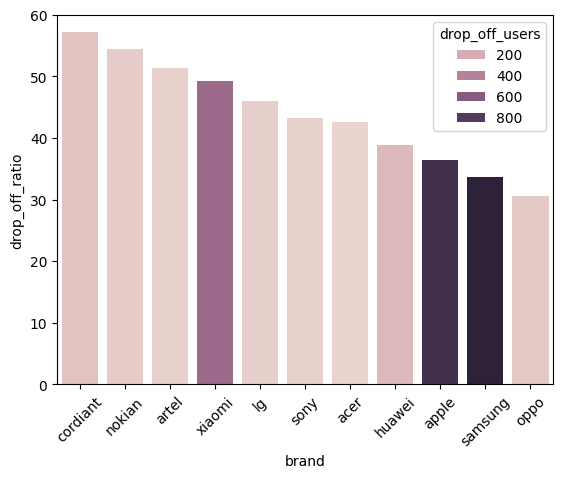

In [36]:
#יצירת בר - גרף לויזואליזציה של הדאטה עבור מנהל החנות

df = pd.read_sql(drop_off_ratio_brand, conn)
sns.barplot(data=df, x='brand', y='drop_off_ratio', hue='drop_off_users')
plt.xticks(rotation=45)